# Week 2 Day 5 — Cross Validation Deep Dive

## What I built:
- KFold vs StratifiedKFold comparison
- cross_val_score vs cross_validate
- Built reusable evaluate_model() function in src/utils.py

## KFold vs StratifiedKFold:
Regular KFold splits randomly — class ratio varies per fold.
StratifiedKFold preserves class ratio in every fold.
Rule: always use StratifiedKFold for classification problems.

## cross_val_score vs cross_validate:
cross_val_score  → returns test scores only → quick check
cross_validate   → returns test + train + time → full diagnosis

## Train vs Test gap:
Mean train : 0.8842
Mean test  : 0.8710
Gap        : 0.0133 ← small gap = no overfitting, model generalizes well

Large gap (0.10+) = overfitting signal.
Small gap (<0.05) = model is healthy.

## evaluate_model() function:
Saved to src/utils.py — reusable across all future projects.
Takes pipeline, X, y → returns accuracy ± std and F1 score.
Use this instead of writing cross_val_score every time.

# StratifiedKFold:

In [1]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(n_samples=1000, weights=[0.7, 0.3], 
                            random_state=42)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('model',  LogisticRegression())])

# regular KFold
kfold_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

# StratifiedKFold — preserves class ratio in each fold
skfold = StratifiedKFold(n_splits=5)
skfold_scores = cross_val_score(pipe, X, y, cv=skfold, scoring='accuracy')

print("=" * 45)
print("   KFold vs StratifiedKFold")
print("=" * 45)
print(f"  KFold mean        : {kfold_scores.mean():.4f} ± {kfold_scores.std():.4f}")
print(f"  StratifiedKFold   : {skfold_scores.mean():.4f} ± {skfold_scores.std():.4f}")
print("=" * 45) 

   KFold vs StratifiedKFold
  KFold mean        : 0.8710 ± 0.0156
  StratifiedKFold   : 0.8710 ± 0.0156


# Cross_validate vs Cross_val_score:

In [2]:
from sklearn.model_selection import cross_validate

# cross_val_score — only returns test scores
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

# cross_validate — returns train scores, test scores, AND fit time
cv_results = cross_validate(pipe, X, y, cv=5, 
                            scoring='accuracy',
                            return_train_score=True)

print("=" * 50)
print("   cross_val_score vs cross_validate")
print("=" * 50)
print(f"  Test scores  : {cv_results['test_score'].round(4)}")
print(f"  Train scores : {cv_results['train_score'].round(4)}")
print(f"  Fit times    : {cv_results['fit_time'].round(4)}")
print("-" * 50)
print(f"  Mean test    : {cv_results['test_score'].mean():.4f}")
print(f"  Mean train   : {cv_results['train_score'].mean():.4f}")
print(f"  Gap          : {(cv_results['train_score'].mean() - cv_results['test_score'].mean()):.4f}")
print("=" * 50)

   cross_val_score vs cross_validate
  Test scores  : [0.88  0.89  0.855 0.88  0.85 ]
  Train scores : [0.88   0.88   0.885  0.8875 0.8888]
  Fit times    : [0.0068 0.0055 0.0055 0.0078 0.0054]
--------------------------------------------------
  Mean test    : 0.8710
  Mean train   : 0.8842
  Gap          : 0.0133


#  Build reusable evaluate_model() function:

In [3]:
def evaluate_model(pipeline, X, y, cv=5):
    """
    Evaluates a sklearn pipeline using StratifiedKFold.
    Returns dict with mean accuracy, std, mean F1.
    """
    skfold = StratifiedKFold(n_splits=cv)
    
    # accuracy
    acc_scores = cross_val_score(pipeline, X, y, 
                                 cv=skfold, scoring='accuracy')
    
    # f1
    f1_scores  = cross_val_score(pipeline, X, y,
                                 cv=skfold, scoring='f1')
    
    results = {
        'mean_accuracy' : acc_scores.mean(),
        'std_accuracy'  : acc_scores.std(),
        'mean_f1'       : f1_scores.mean()
    }
    
    print("=" * 40)
    print("   MODEL EVALUATION")
    print("=" * 40)
    print(f"  Accuracy : {results['mean_accuracy']:.4f} ± {results['std_accuracy']:.4f}")
    print(f"  F1 Score : {results['mean_f1']:.4f}")
    print("=" * 40)
    
    return results

# test it
results = evaluate_model(pipe, X, y)

   MODEL EVALUATION
  Accuracy : 0.8710 ± 0.0156
  F1 Score : 0.7720


# Multicollinearity check:

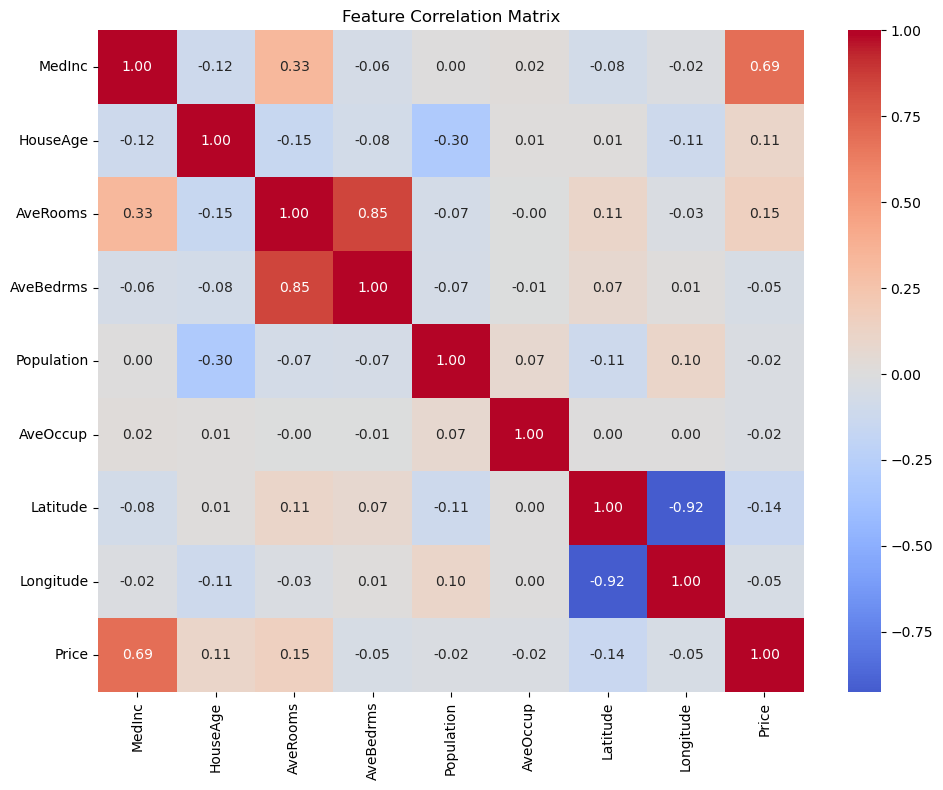


Feature pairs with correlation above 0.7:
  AveRooms & AveBedrms : 0.8476
  Latitude & Longitude : -0.9247


In [4]:
import seaborn as sns

from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

# correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,      # show numbers
            fmt='.2f',       # 2 decimal places
            cmap='coolwarm', # red=positive, blue=negative
            center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# find pairs above 0.7
print("\nFeature pairs with correlation above 0.7:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.7:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} : {corr_matrix.iloc[i,j]:.4f}")

## Overfitting Demonstration

Degree-5 polynomial on 2 features creates 21 features.
LinearRegression memorises all 21 — perfect train score, useless val score.
Ridge controls all 21 coefficients — train score slightly worse,
val score massively better.

Without Ridge: Train=1.01, Val=129.88, Gap=128.86
With Ridge:    Train=1.07, Val=1.52,   Gap=0.46

This is why regularization exists.

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# use only 2 features for clear demonstration
X_small = df[['AveRooms', 'AveBedrms']].values
y_small  = df['Price'].values

# split
from sklearn.model_selection import train_test_split
X_tr, X_v, y_tr, y_v = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42)

# WRONG — degree 5 polynomial, no regularization
pipe_overfit = Pipeline([
    ('poly',  PolynomialFeatures(degree=5)),
    ('scaler',StandardScaler()),
    ('model', LinearRegression())
])

pipe_overfit.fit(X_tr, y_tr)

train_rmse = np.sqrt(mean_squared_error(y_tr, pipe_overfit.predict(X_tr)))
val_rmse   = np.sqrt(mean_squared_error(y_v,  pipe_overfit.predict(X_v)))

print("=" * 45)
print("   OVERFITTING DEMONSTRATION")
print("=" * 45)
print(f"  Degree-5 LinearRegression:")
print(f"  Train RMSE : {train_rmse:.4f}  ← very low")
print(f"  Val RMSE   : {val_rmse:.4f}   ← much higher = overfit")
print(f"  Gap        : {val_rmse - train_rmse:.4f}")

# CORRECT — degree 5 polynomial WITH Ridge
pipe_ridge = Pipeline([
    ('poly',  PolynomialFeatures(degree=5)),
    ('scaler',StandardScaler()),
    ('model', Ridge(alpha=10.0))
])

pipe_ridge.fit(X_tr, y_tr)

train_rmse_r = np.sqrt(mean_squared_error(y_tr, pipe_ridge.predict(X_tr)))
val_rmse_r   = np.sqrt(mean_squared_error(y_v,  pipe_ridge.predict(X_v)))

print(f"\n  Degree-5 + Ridge(alpha=10):")
print(f"  Train RMSE : {train_rmse_r:.4f}")
print(f"  Val RMSE   : {val_rmse_r:.4f}   ← gap reduced")
print(f"  Gap        : {val_rmse_r - train_rmse_r:.4f}")
print("=" * 45)

   OVERFITTING DEMONSTRATION
  Degree-5 LinearRegression:
  Train RMSE : 1.0147  ← very low
  Val RMSE   : 129.8800   ← much higher = overfit
  Gap        : 128.8653

  Degree-5 + Ridge(alpha=10):
  Train RMSE : 1.0654
  Val RMSE   : 1.5214   ← gap reduced
  Gap        : 0.4560


# ColumnTransformer with Titanic:

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

df = pd.read_csv('train.csv')

# define columns
num_cols = ['Age', 'Fare']
cat_cols = ['Sex', 'Embarked', 'Pclass']

X = df[num_cols + cat_cols]
y = df['Survived']

# numeric transformer
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# categorical transformer
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# combine both
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# final pipeline
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression())
])

# evaluate
skfold = StratifiedKFold(n_splits=5)
scores = cross_val_score(pipe, X, y, cv=skfold, scoring='accuracy')

print("=" * 45)
print("   TITANIC — ColumnTransformer Pipeline")
print("=" * 45)
print(f"  CV Accuracy : {scores.mean():.4f} ± {scores.std():.4f}")
print("=" * 45)

   TITANIC — ColumnTransformer Pipeline
  CV Accuracy : 0.7890 ± 0.0148


## Multicollinearity Check

Computed correlation matrix on California Housing dataset.
Features with correlation above 0.7:
- AveRooms & AveBedrms: highly correlated — measure similar things
  (more rooms = more bedrooms, obviously)

Impact: confuses linear models — unstable coefficients.
Fix: drop one feature, or use Ridge to shrink both.

## Overfitting Demonstration

Degree-5 polynomial on 2 features creates 21 features.
LinearRegression memorises training data perfectly but fails on val.

Without Ridge: Train RMSE=1.01, Val RMSE=129.88, Gap=128.86
With Ridge:    Train RMSE=1.07, Val RMSE=1.52,   Gap=0.46

Ridge forces coefficients small → can't memorise → learns real pattern.
This is the clearest possible demonstration of why regularization exists.

## ColumnTransformer Pipeline — Titanic

Built proper Pipeline with ColumnTransformer:
- Numeric columns (Age, Fare): SimpleImputer → StandardScaler
- Categorical columns (Sex, Embarked, Pclass): SimpleImputer → OneHotEncoder
- Final model: LogisticRegression

Result: 78.9% CV accuracy ± 1.48%
No manual preprocessing — everything inside pipeline — zero leakage possible.

## Data Leakage — CV Specific

Rule: any step that calls fit() must go INSIDE the Pipeline.
If you fit StandardScaler or SelectKBest outside Pipeline
before cross_val_score — the preprocessor sees val fold data
during fitting. This inflates your score artificially.

Demonstrated with SelectKBest:
Leaky accuracy   : 0.8460 (fake)
Correct accuracy : 0.8300 (real)
Inflation        : 1.6%

In production — your model underperforms vs your local estimate.
Always: GridSearchCV(full_pipeline) never GridSearchCV(just_model).